<a href="https://colab.research.google.com/github/Dhanushgowda2342/AIML-journey/blob/main/logistic_regression(diabetes).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mathchi/diabetes-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-data-set' dataset.
Path to dataset files: /kaggle/input/diabetes-data-set


In [2]:
import pandas as pd
import os

In [3]:
print(os.listdir(path))

['diabetes.csv']


In [4]:
df = pd.read_csv(os.path.join(path,"diabetes.csv"))

In [5]:
df = pd.read_csv(path+"/diabetes.csv")

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.shape

(768, 9)

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
175,8,179,72,42,130,32.7,0.719,36,1
123,5,132,80,0,0,26.8,0.186,69,0
335,0,165,76,43,255,47.9,0.259,26,0
218,5,85,74,22,0,29.0,1.224,32,1
420,1,119,88,41,170,45.3,0.507,26,0


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

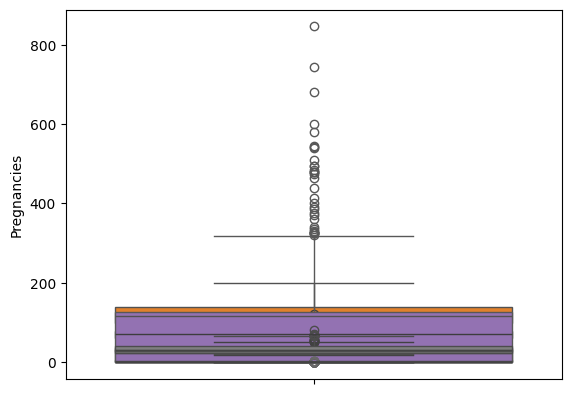

In [14]:
box_columns=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
for col in box_columns:
  sns.boxplot(df[col])

<Axes: xlabel='Pregnancies'>

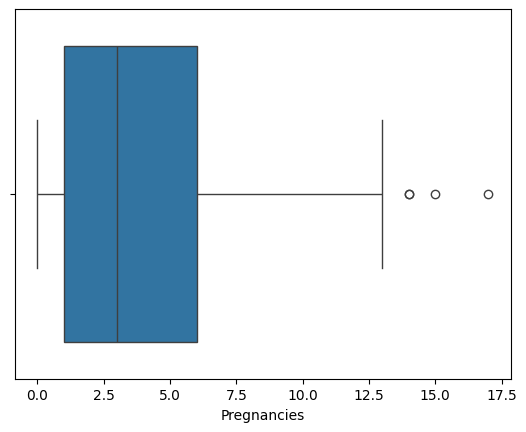

In [15]:
sns.boxplot(x=df['Pregnancies'])

In [16]:
#replacing 0 value with median
median_bmi=df[df['BMI'] != 0]['BMI'].median()
print(median_bmi)
df['BMI']=df['BMI'].replace(0,median_bmi)

32.3


In [17]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols:
  median=df[df[col]!=0][col].median()
  df[col]=df[col].replace(0,median)

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [20]:
y=df['Outcome']
X=df.drop('Outcome',axis=1)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test)

In [24]:
new_patient =pd.DataFrame([[2, 120, 70, 20, 85, 32.0, 0.5, 30]],columns=X.columns)
model.predict(new_patient)

array([0])

In [25]:
model.predict_proba(new_patient)

array([[0.7636075, 0.2363925]])

In [26]:
for col, coef in zip(X.columns, model.coef_[0]):
    print(col, coef)

Pregnancies 0.0606462343693129
Glucose 0.0399391280920857
BloodPressure -0.009143341348232076
SkinThickness 0.004140235718361503
Insulin -0.0005643596652813664
BMI 0.10879807463012556
DiabetesPedigreeFunction 0.2885102178239343
Age 0.033131573011750834


In [27]:
# Logistic Regression Coefficient Interpretation

# Each coefficient represents how much a feature affects the prediction (log-odds).

# SIGN of coefficient:
# +ve → increases probability of diabetes (class 1)
# -ve → decreases probability of diabetes (class 0)

# MAGNITUDE of coefficient:
# Larger value → stronger influence on prediction
# Smaller value → weaker influence

# From our model:

# DiabetesPedigreeFunction (0.288) → strongest feature
# → family history has major impact on diabetes risk

# BMI (0.108) → important factor
# → higher BMI increases diabetes probability

# Pregnancies (0.060) → moderate effect

# Glucose (0.039) → contributes to diabetes risk

# Age (0.033) → smaller positive effect

# BloodPressure (-0.009) → slightly reduces probability

# Insulin (-0.0005) → almost no effect (very weak feature)

# SkinThickness (0.004) → very low impact

# IMPORTANT NOTE:
# Coefficients depend on feature scale.
# So direct comparison may not always be perfectly accurate.

# SUMMARY:
# Model combines all features using weights (coefficients)
# to calculate a score (z), then converts it into probability using sigmoid.

In [28]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

In [29]:
model_l1.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

In [30]:
model.coef_        # L2
model_l1.coef_     # L1

array([[ 0.05891646,  0.03772175, -0.01321759,  0.00251146, -0.00049764,
         0.10000006,  0.1814623 ,  0.03133381]])

In [31]:
# cross validation
from sklearn.linear_model import LogisticRegressionCV
model_cv = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1, 10],   # values to try
    cv=5,                           # 5-fold cross-validation
    penalty='l2',                   # start with L2
    solver='lbfgs',
    max_iter=1000
)
model_cv.fit(X_train, y_train)
print("Best C:", model_cv.C_)

Best C: [10.]


In [32]:
model.predict_proba(X_test)

array([[0.74578177, 0.25421823],
       [0.8187451 , 0.1812549 ],
       [0.89184186, 0.10815814],
       [0.8780944 , 0.1219056 ],
       [0.51199636, 0.48800364],
       [0.55950211, 0.44049789],
       [0.98975277, 0.01024723],
       [0.65315901, 0.34684099],
       [0.39854702, 0.60145298],
       [0.21543372, 0.78456628],
       [0.78621948, 0.21378052],
       [0.08182332, 0.91817668],
       [0.54929956, 0.45070044],
       [0.77481101, 0.22518899],
       [0.94568412, 0.05431588],
       [0.64694806, 0.35305194],
       [0.89173982, 0.10826018],
       [0.93837637, 0.06162363],
       [0.23409633, 0.76590367],
       [0.3811536 , 0.6188464 ],
       [0.81808577, 0.18191423],
       [0.93176637, 0.06823363],
       [0.51503251, 0.48496749],
       [0.91193831, 0.08806169],
       [0.4283793 , 0.5716207 ],
       [0.09166909, 0.90833091],
       [0.90178953, 0.09821047],
       [0.97358828, 0.02641172],
       [0.70308424, 0.29691576],
       [0.90866743, 0.09133257],
       [0.

In [36]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1])
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.7968543046357617
